In [1]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json


L = 2  # take a 2x2 lattice
D = 2
t = 1  # tunneling/hopping
U = 0.01  # coulomb

# create the graph our fermions can hop on
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=True)
n_sites = g.n_nodes

# create a hilbert space with 2 up and 2 down spins
hi = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))

# Option 1: create an operator representing fermi hubbard interactions by hand


# -t (i^ j + h.c.) + U (i^ i j^ j)
# we will create a helper function to abbreviate the creation, destruction and number operators
# each operator has a site and spin projection (sz) in order to find the right position in the hilbert space samples
def c(site, sz):
    return nk.operator.fermion.destroy(hi, site, sz=sz)


def cdag(site, sz):
    return nk.operator.fermion.create(hi, site, sz=sz)


def nc(site, sz):
    return nk.operator.fermion.number(hi, site, sz=sz)


up = +1
down = -1
ham = 0.0
for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) * c(v, sz) - t * cdag(v, sz) * c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) * nc(u, down)

print("Hamiltonian =", ham.operator_string())

# The Fermi-hubbard hamiltonian conserves the number of fermions, which the generic operator we just defined does not exploit,
# and thus it creates more (zero) connected elements than necessary.
# We could set max_conn_size to remove them inside the operator, or,
# better, directly use the a more efficient implementation included in netket:
# Convert to ParticleNumberAndSpinConservingFermioperator2nd


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hamiltonian = -1.0 [6^ 7] +
-1.0 [7^ 6] +
-1.0 [4^ 6] +
-1.0 [6^ 4] +
-1.0 [5^ 7] +
-1.0 [7^ 5] +
-1.0 [4^ 5] +
-1.0 [5^ 4] +
-1.0 [2^ 3] +
-1.0 [3^ 2] +
-1.0 [0^ 2] +
-1.0 [2^ 0] +
-1.0 [1^ 3] +
-1.0 [3^ 1] +
-1.0 [0^ 1] +
-1.0 [1^ 0] +
0.01 [4^ 4 0^ 0] +
0.01 [5^ 5 1^ 1] +
0.01 [6^ 6 2^ 2] +
0.01 [7^ 7 3^ 3]


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/graph/common_lattices.py:126: InitializePeriodicLatticeOnSmallLatticeWarning: 
You are attempting to define a lattice with length 2 in dimension 0 using periodic boundary condition.

Lattice with less than two sites in one direction does not support periodic boundary condition.
The behavior of the lattice is equivalent to an open boundary condition in this direction.

To avoid this warning, consider either using a lattice with more than two sites in the direction you want to be periodic,
or define the graph using :class:`~netket.graph.Graph` by adding the edges manually.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.InitializePeriodicLatticeOnSmallLatticeWarning.html
or the list of all common errors and warnings at
	 https://netket.readthedocs.io/en/latest/api/errors.html
-----

In [2]:
for u, v in g.edges():
    print(u,v)

2 3
0 2
1 3
0 1


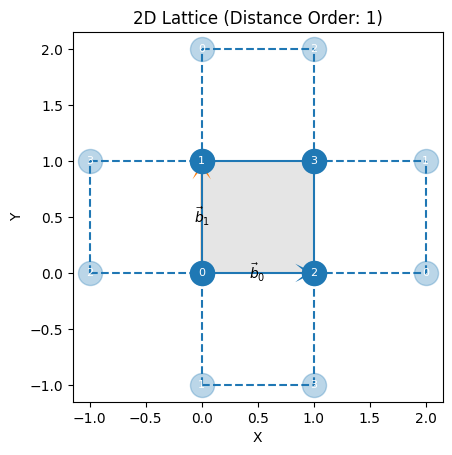

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [3]:
g.draw()

In [4]:
g.edges()

[(2, 3), (0, 2), (1, 3), (0, 1)]